# EDA — EDB & JAAF Apparel Export Data

This notebook explores the two national trade-data sources currently feeding
CeyNex's `fact_trade` table for the Apparel & Textiles sector:

| `source_id` | Publisher | What it is | Frequency | Connector |
|---|---|---|---|---|
| **EDB** | Sri Lanka Export Development Board | "Export Performance Indicators" report — export value by destination market, per apparel/textile sub-category | Annual | `ceynex/data/connectors/edb.py` |
| **JAAF** | Joint Apparel Association Forum | "Annual Exports" / "Market Wise Exports" pages — Total / US / UK export value | Monthly | `ceynex/data/connectors/jaaf.py` |

Both connectors write into the same `fact_trade`-shaped staging table
(`data/staging/fact_trade_apparel.parquet`), so this notebook reads that
single unioned table and filters to these two sources rather than re-parsing
raw PDFs/HTML. See `data/raw/edb/PROFILE.md` and `data/raw/jaaf/PROFILE.md`
for the connector-level ground truth this EDA is checked against.

**What this notebook covers:** structure & missingness, item-taxonomy quality
(these two sources are messier than the schema alone suggests), coverage by
year/partner, trends, seasonality, a naive-sum double-counting trap, a
cross-source consistency check, and a running list of data-quality findings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import difflib
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 80)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

USD_MN = 1_000_000  # export_value_usd is in raw USD; divide by this for USD millions

## 1. Load & scope the data

`data/staging/fact_trade_apparel.parquet` is the crosswalked, unioned output
of every connector's `to_fact_trade`. We filter to `source_id in {EDB, JAAF}`
and leave everything else (Comtrade, FAOSTAT, teaboard, etc.) out of scope.

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise FileNotFoundError("pyproject.toml not found above " + str(start))

REPO_ROOT = find_repo_root(Path.cwd())
DATA_ROOT = REPO_ROOT / "data"

fact = pd.read_parquet(DATA_ROOT / "staging" / "fact_trade_apparel.parquet")
df = fact[fact["source_id"].isin(["EDB", "JAAF"])].copy()

df["period_start"] = pd.to_datetime(df["period_start"])
df["period_end"] = pd.to_datetime(df["period_end"])
df["year"] = df["period_start"].dt.year
df["month"] = df["period_start"].dt.month
df["value_usd_mn"] = df["export_value_usd"] / USD_MN

print(f"staging table: {len(fact):,} rows, sources = {sorted(fact['source_id'].unique())}")
print(f"EDB + JAAF slice: {len(df):,} rows")
df.head()

staging table: 7,610 rows, sources = ['EDB', 'JAAF']
EDB + JAAF slice: 7,610 rows


,source_id,sector,item,hs_code,reporter_iso3,reporter_m49,partner_iso3,partner_m49,period_start,period_end,frequency,export_volume,volume_unit,export_value_usd,price,price_unit,fx_usd_lkr,source_hash,year,month,value_usd_mn
0,EDB,apparel,"APPAREL & TEXTILES (Made - Up Textile Article, Apparel, Woven Fabrics & Othe...",None,LKA,144,USA,842.0,2019-01-01,2019-12-31,A,None,None,2.380990e+09,None,None,None,b91baf3aea9702477cab9d3f0491e4fe49ab2bd61c3f4cd0d59559a290df03c2,2019,1,2380.99
1,EDB,apparel,"APPAREL & TEXTILES (Made - Up Textile Article, Apparel, Woven Fabrics & Othe...",None,LKA,144,USA,842.0,2020-01-01,2020-12-31,A,None,None,1.806420e+09,None,None,None,a6738ef4a3e2aa43e85b82168ee711b4074ca574a75c80faa314b09d4596163b,2020,1,1806.42
2,EDB,apparel,"APPAREL & TEXTILES (Made - Up Textile Article, Apparel, Woven Fabrics & Othe...",None,LKA,144,USA,842.0,2021-01-01,2021-12-31,A,None,None,2.124540e+09,None,None,None,25a16e9294255aea993aad616a655294049552866c8ea2519ea93802e109ede6,2021,1,2124.54
3,EDB,apparel,"APPAREL & TEXTILES (Made - Up Textile Article, Apparel, Woven Fabrics & Othe...",None,LKA,144,USA,842.0,2022-01-01,2022-12-31,A,None,None,2.344970e+09,None,None,None,f5d64ed3fea28d3c709189364525877bae39dbce60332d406ccf165a4043aa12,2022,1,2344.97
4,EDB,apparel,"APPAREL & TEXTILES (Made - Up Textile Article, Apparel, Woven Fabrics & Othe...",None,LKA,144,USA,842.0,2023-01-01,2023-12-31,A,None,None,1.824420e+09,None,None,None,646fdbf39b2a1ce0673b3a3e318c21ec7b52664ab55e79d73ebc6c8b374679e3,2023,1,1824.42


## 2. Shape, dtypes, and a first look

In [3]:
print(df.shape)
df.dtypes

(7610, 21)


source_id                      str
sector                         str
item                           str
hs_code                     object
reporter_iso3                  str
reporter_m49                 int64
partner_iso3                   str
partner_m49                float64
period_start        datetime64[us]
period_end          datetime64[us]
frequency                      str
export_volume               object
volume_unit                 object
export_value_usd           float64
price                       object
price_unit                  object
fx_usd_lkr                  object
source_hash                    str
year                         int32
month                        int32
value_usd_mn               float64
dtype: object

In [4]:
df[["source_id", "sector", "item", "reporter_iso3", "partner_iso3",
    "period_start", "period_end", "frequency", "value_usd_mn"]].sample(8, random_state=0)

,source_id,sector,item,reporter_iso3,partner_iso3,period_start,period_end,frequency,value_usd_mn
311,EDB,apparel,APPREL,LKA,MYS,2020-01-01,2020-12-31,A,8.22
4970,EDB,apparel,ACTIVEWEAR/ SPORTSWERA,LKA,THA,2020-01-01,2020-12-31,A,0.05
527,EDB,apparel,MEN'S & WOMEN'S UNDER GARMENTS,LKA,TWN,2022-01-01,2022-12-31,A,2.04
6525,EDB,apparel,WOVEN FABRICS,LKA,MEX,2014-01-01,2014-12-31,A,0.35
800,EDB,apparel,MEN'S OUTERWEAR,LKA,USA,2022-01-01,2022-12-31,A,353.78
3074,EDB,apparel,"APPAREL & TEXTILES (Made - Up Textile Article, Apparel, Woven Fabrics & Othe...",LKA,FRA,2020-01-01,2020-12-31,A,78.68
1833,EDB,apparel,ACTIVEWEAR/ SPORTSWERA,LKA,ARE,2022-01-01,2022-12-31,A,0.90
2272,EDB,apparel,"MADE - UP TEXTILE ARTICLES (Blankets, Rugs, Linen & Curtains etc.)",LKA,CZE,2019-01-01,2019-12-31,A,0.15


## 3. Missingness

`fact_trade` is a wide schema shared across every connector (Comtrade,
FAOSTAT, teaboard, pinksheet, ...). EDB and JAAF only populate a subset of
its columns — a 100% null rate below is not necessarily a defect, it can
just mean "this source has no concept of that field" (e.g. neither source
publishes physical export *volume*, only *value*).

In [5]:
missing = df.isna().mean().sort_values(ascending=False).rename("null_rate").to_frame()
missing["null_rate"] = (missing["null_rate"] * 100).round(1).astype(str) + "%"
missing

,null_rate
hs_code,100.0%
price,100.0%
price_unit,100.0%
volume_unit,100.0%
export_volume,100.0%
fx_usd_lkr,100.0%
partner_iso3,3.6%
partner_m49,3.6%
source_id,0.0%
reporter_iso3,0.0%


In [6]:
# reporter is always Sri Lanka for both sources (sanity check, not a finding)
print("reporter_iso3 unique:", df["reporter_iso3"].unique())

# the only column with partial (not 0% / 100%) nulls is partner_iso3 -- who has them, and why?
null_partner = df[df["partner_iso3"].isna()]
print(f"\nnull partner_iso3: {len(null_partner)} rows, all from source_id = {null_partner['source_id'].unique().tolist()}")
print(f"as a share of that source's rows: {len(null_partner) / len(df[df.source_id=='JAAF']):.1%}")

reporter_iso3 unique: <ArrowStringArray>
['LKA']
Length: 1, dtype: str

null partner_iso3: 276 rows, all from source_id = ['JAAF']
as a share of that source's rows: 41.9%


**Finding:** every null `partner_iso3` row is JAAF, and it's not a parsing
gap — it's the JAAF "Total" (world-aggregate) market table, which by
definition has no single bilateral partner. `partner_iso3`/`partner_m49`
being null there is expected, not missing data. The genuinely bilateral JAAF
rows (`US`, `UK`) are fully populated.

`hs_code`, `export_volume`, `volume_unit`, `price`, `price_unit`,
`fx_usd_lkr` are 100% null for **both** sources — neither EDB's PDF tables
nor JAAF's HTML pages report physical volume, unit price, or an FX rate,
only USD export value. That's a schema-vs-source mismatch to keep in mind
for any downstream feature that expects volume or price (e.g. a
price-elasticity model needs a source that actually populates `price`).

## 4. Coverage per source

In [7]:
coverage = df.groupby("source_id").agg(
    rows=("source_hash", "size"),
    frequency=("frequency", "first"),
    first_period=("period_start", "min"),
    last_period=("period_end", "max"),
    n_items=("item", "nunique"),
    n_partners=("partner_iso3", "nunique"),
    total_value_usd_bn=("export_value_usd", lambda s: s.sum() / 1e9),
).reset_index()
coverage

,source_id,rows,frequency,first_period,last_period,n_items,n_partners,total_value_usd_bn
0,EDB,6952,A,2014-01-01,2024-12-31,22,95,200.55216
1,JAAF,658,M,2004-01-01,2026-12-31,1,2,141.85814


Note `total_value_usd_bn` here is a **naive sum across every row** — it is
not a meaningful "total exports" figure yet, for two separate reasons
uncovered below: exact duplicate rows (§5) and a category hierarchy that
isn't a flat partition (§7). Treat this row only as a coverage sanity check,
not a headline number.

## 5. Duplicate rows — a real bug, not just a hash sanity check

A naive `source_hash` uniqueness check turns out to matter here, not just
as boilerplate.

In [8]:
dupe_hashes = df["source_hash"].duplicated().sum()
print(f"duplicate source_hash values: {dupe_hashes} / {len(df):,} ({dupe_hashes/len(df):.1%})")

biz_key = ["source_id", "item", "partner_iso3", "period_start", "period_end"]
biz_dupes = df.duplicated(subset=biz_key, keep=False).sum()
print(f"rows involved in a duplicate (source, item, partner, period) combination: {biz_dupes}")

by_source = df.assign(is_dupe=df["source_hash"].duplicated()).groupby("source_id")["is_dupe"].sum()
by_source

duplicate source_hash values: 2059 / 7,610 (27.1%)
rows involved in a duplicate (source, item, partner, period) combination: 4118


source_id
EDB     2059
JAAF       0
Name: is_dupe, dtype: int64

All of it is EDB. Let's find out why.

In [9]:
edb_agg_item = "APPAREL & TEXTILES (Made - Up Textile Article, Apparel, Woven Fabrics & Other Textile Articles)"

sample_dupe = df[(df["item"] == edb_agg_item) & (df["partner_iso3"] == "USA")]
sample_dupe[["year", "partner_iso3", "value_usd_mn", "source_hash"]].sort_values("year")

,year,partner_iso3,value_usd_mn,source_hash
0,2019,USA,2380.99,b91baf3aea9702477cab9d3f0491e4fe49ab2bd61c3f4cd0d59559a290df03c2
1,2020,USA,1806.42,a6738ef4a3e2aa43e85b82168ee711b4074ca574a75c80faa314b09d4596163b
3039,2020,USA,1806.42,a6738ef4a3e2aa43e85b82168ee711b4074ca574a75c80faa314b09d4596163b
2,2021,USA,2124.54,25a16e9294255aea993aad616a655294049552866c8ea2519ea93802e109ede6
3040,2021,USA,2124.54,25a16e9294255aea993aad616a655294049552866c8ea2519ea93802e109ede6
3,2022,USA,2344.97,f5d64ed3fea28d3c709189364525877bae39dbce60332d406ccf165a4043aa12
3041,2022,USA,2344.97,f5d64ed3fea28d3c709189364525877bae39dbce60332d406ccf165a4043aa12
4,2023,USA,1824.42,646fdbf39b2a1ce0673b3a3e318c21ec7b52664ab55e79d73ebc6c8b374679e3
3042,2023,USA,1824.42,646fdbf39b2a1ce0673b3a3e318c21ec7b52664ab55e79d73ebc6c8b374679e3
3043,2024,USA,1916.60,24c5a55f849564355f02134fa526ea97021a249e9c4805492348f519d31c3dae


In [10]:
rows_per_year = (
    df[df["item"] == edb_agg_item]
    .groupby(["year", "partner_iso3"]).size()
    .groupby("year").agg(avg_rows_per_partner="mean", max_rows_for_a_partner="max")
)
rows_per_year

,avg_rows_per_partner,max_rows_for_a_partner
year,,
2019,1.000000,1
2020,1.904762,2
2021,1.904762,2
2022,1.904762,2
2023,1.904762,2
2024,1.000000,1


**Root cause:** EDB publishes overlapping multi-year editions — the 2023
edition's tables cover 2019-2023, the 2024 edition's cover 2020-2024. The
connector correctly parses each PDF independently, but `to_fact_trade`
melts *both* editions into `fact_trade` without deduplicating the years
they share (2020-2023). The result: every (market, year) cell in that
4-year overlap window is **counted twice**, with byte-for-byte identical
`export_value_usd` and `source_hash` — not a values conflict, a literal
duplicate row. `edb.PROFILE.md` documents that `table_id` isn't a stable
key *across* editions, but doesn't mention that the two editions' *outputs*
overlap in `fact_trade` at all — this is a new finding.

This silently roughly **doubles** 2020-2023 in any naive
`groupby(year).sum()`, which is exactly the kind of thing that would have
made §14's year-over-year growth chart wrong in a hard-to-notice way (a
growth spike that's really a duplication artifact, not a business fact) had
it not been deduplicated here first. **Deduplicating now, before any further
analysis**, on `source_hash` (the connector's own designed-for-this
content hash):

In [11]:
before = len(df)
df = df.drop_duplicates(subset="source_hash").copy()
print(f"{before:,} rows -> {len(df):,} rows ({before - len(df):,} exact duplicates removed, all EDB)")

7,610 rows -> 5,551 rows (2,059 exact duplicates removed, all EDB)


## 6. EDB item taxonomy quality

`edb.PROFILE.md` already flags that the "annual" and "archive" PDF layouts
use different, non-identical category sets, and that product-name wording
drifts edition to edition. Let's see exactly how messy that is in practice.

In [12]:
edb_items = sorted(df.loc[df["source_id"] == "EDB", "item"].unique())
print(f"{len(edb_items)} distinct EDB item labels for what is, editorially, ~13-17 categories:\n")
for it in edb_items:
    print(" -", it)

22 distinct EDB item labels for what is, editorially, ~13-17 categories:

 - ACTIVEWEAR/ SPORTSWERA
 - APPAREL
 - APPAREL & TEXTILES (Made - Up Textile Article, Apparel, Woven Fabrics & Other Textile Articles)
 - APPAREL AND TEXTILES (Made – Up Textile Articles, Apparel, Woven Fabrics, Other Textile Articles)
 - APPREL
 - BABIES' GARMENTS
 - GLOVES, MITTS & MITTENS OF TEXTILE
 - HOSIERY
 - KNITTED FABRICS
 - MADE - UP CLOTHING ACCESSORIES (Handkerchief, Shawls, Scarves, Ties etc)
 - MADE - UP TEXTILE ARTICLES (Blankets, Rugs, Linen & Curtains etc.)
 - MADE – UP TEXTILE ARTICLES
 - MADE-UP TEXTILE ARTICLES (Blankets, Rugs, Linen, Curtains etc)
 - MEN'S & WOMEN'S UNDER GARMENTS
 - MEN'S OUTERWEAR
 - T-SHIRTS
 - TEXTILE FLOOR COVERING (Carpets, Mats, Floor Covering etc)
 - TEXTILES ( Knitted Fabrics, Woven Fabrics, Yarn, Made - Up Textile Articles, Textile Floor Covering etc.)
 - WARM CLOTHS (Jerseys, Pullovers etc.)
 - WOMEN'S OUTERWEAR
 - WOVEN FABRICS
 - YARN


In [13]:
# cluster near-duplicate labels (same category, different punctuation/edition wording)
seen, clusters = set(), []
for a in edb_items:
    if a in seen:
        continue
    close = [c for c in difflib.get_close_matches(a, edb_items, n=6, cutoff=0.55) if c != a]
    if close:
        clusters.append([a, *close])
        seen.update(close)
    seen.add(a)

for c in clusters:
    print("CLUSTER:")
    for label in c:
        print("   ", repr(label))
    print()

CLUSTER:


    'APPAREL'
    'APPREL'

CLUSTER:
    'APPAREL & TEXTILES (Made - Up Textile Article, Apparel, Woven Fabrics & Other Textile Articles)'
    'APPAREL AND TEXTILES (Made – Up Textile Articles, Apparel, Woven Fabrics, Other Textile Articles)'

CLUSTER:
    'KNITTED FABRICS'
    'WOVEN FABRICS'

CLUSTER:
    'MADE - UP CLOTHING ACCESSORIES (Handkerchief, Shawls, Scarves, Ties etc)'
    'MADE - UP TEXTILE ARTICLES (Blankets, Rugs, Linen & Curtains etc.)'

CLUSTER:
    'MADE-UP TEXTILE ARTICLES (Blankets, Rugs, Linen, Curtains etc)'
    'MADE - UP TEXTILE ARTICLES (Blankets, Rugs, Linen & Curtains etc.)'

CLUSTER:
    "MEN'S & WOMEN'S UNDER GARMENTS"
    "WOMEN'S OUTERWEAR"

CLUSTER:
    "MEN'S OUTERWEAR"
    "WOMEN'S OUTERWEAR"



**Findings:**

- **`APPAREL` vs `APPREL`** — a literal typo in the source PDF's own table
  text (`APPREL`, 2019-2024 annual editions) that survives as a *distinct*
  `item` value from `APPAREL` (2014-2018 archive editions). These are the
  same category; nothing in the pipeline currently merges them.
- **Three variants of "Made-Up Textile Articles"** —
  `MADE - UP TEXTILE ARTICLES (Blankets, Rugs, Linen & Curtains etc.)`
  (2019-2023), `MADE-UP TEXTILE ARTICLES (Blankets, Rugs, Linen, Curtains
  etc)` (2020-2024) and `MADE � UP TEXTILE ARTICLES` (2014-2018) — same
  category, drifting punctuation across editions, exactly as
  `edb.PROFILE.md` warns (`table_id` 25.89 is not a stable key across
  editions; this is that same instability showing up in the text itself).
- **A `�` (U+FFFD) replacement character** in `MADE � UP TEXTILE
  ARTICLES` and `APPAREL AND TEXTILES (Made � Up Textile Articles...)`
  — this is new versus what `PROFILE.md` documents: it's mojibake, almost
  certainly an en/em-dash in the source PDF that `pdfplumber`'s text layer
  (or the archive-layout regex) decoded incorrectly for the 2009-2018
  archive file specifically. It's cosmetic (doesn't corrupt the numeric
  columns) but it does mean a naive `item == "..."` string match will never
  match this row — anyone filtering on the "Made-Up Textile Articles"
  label by string equality silently drops the 2014-2018 archive rows.
- Net effect: **there is no single `item` string that means "Made-Up Textile
  Articles" across the full 2014-2024 span** — a consumer needs a normalized
  crosswalk (case-fold, punctuation-strip, dash-normalize) before grouping
  by category across editions. No such normalization exists yet in
  `to_fact_trade` for either connector.

In [14]:
# same drift on the top-level "Apparel & Textiles" aggregate label
agg_labels = [i for i in edb_items if i.upper().startswith("APPAREL A")]
for lbl in agg_labels:
    yrs = sorted(df.loc[df["item"] == lbl, "year"].unique())
    print(f"{yrs[0]}-{yrs[-1]}  {lbl!r}")

2014-2018  'APPAREL AND TEXTILES (Made – Up Textile Articles, Apparel, Woven Fabrics, Other Textile Articles)'


## 7. The double-counting trap

EDB's `item` values are a **category hierarchy** for a given edition (a
top-level "Apparel & Textiles" total plus ~12-16 overlapping sub-categories
like Woven Fabrics, Yarn, T-Shirts...), not a flat partition. Summing
`export_value_usd` across *all* items per year overstates real exports by
roughly the number of overlapping category levels.

In [15]:
naive = (
    df[df["source_id"] == "EDB"]
    .groupby("year")["value_usd_mn"].sum()
    .rename("naive_sum_all_items_usd_mn")
    .round(0)
)
naive.to_frame()

,naive_sum_all_items_usd_mn
year,
2014,9638.0
2015,9423.0
2016,9545.0
2017,9835.0
2018,10393.0
2019,16286.0
2020,13083.0
2021,15970.0
2022,17539.0


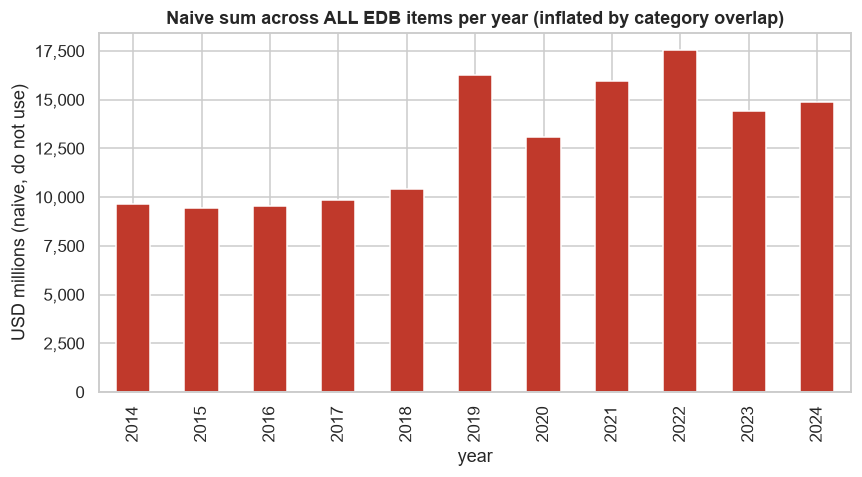

In [16]:
# Sri Lanka's actual apparel+textile exports run ~USD 4.5-5.5bn/yr in this
# period -- the naive per-item sum is several times that, confirming
# double counting rather than a plausible total.
fig, ax = plt.subplots(figsize=(8, 4.5))
naive.plot(kind="bar", ax=ax, color="#c0392b")
ax.set_title("Naive sum across ALL EDB items per year (inflated by category overlap)")
ax.set_ylabel("USD millions (naive, do not use)")
ax.set_xlabel("year")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.tight_layout()
plt.show()

The fix is to pick **one** top-level aggregate `item` per edition rather
than summing the hierarchy. Section 8 does that (using the normalized
label groups found in section 6).

## 8. EDB — total apparel & textiles export value by year (corrected)

In [17]:
# normalize the punctuation/mojibake drift found in section 6 so the same
# real-world category groups together across editions
def normalize_item(label: str) -> str:
    return (
        label.upper()
        .replace("�", "-")
        .replace("–", "-")
        .replace("&", "AND")
        .replace(",", "")
        .split("(")[0]
        .strip()
    )

df["item_norm"] = df["item"].map(normalize_item)

edb_total_label = "APPAREL AND TEXTILES"
edb_total = (
    df[(df["source_id"] == "EDB") & (df["item_norm"] == edb_total_label)]
    .groupby("year")["value_usd_mn"].sum()
)
edb_total

year
2014    4828.45
2015    4714.65
2016    4783.27
2017    4931.55
2018    5213.91
2019    5453.63
2020    4316.69
2021    5308.75
2022    5833.40
2023    4790.31
2024    4969.27
Name: value_usd_mn, dtype: float64

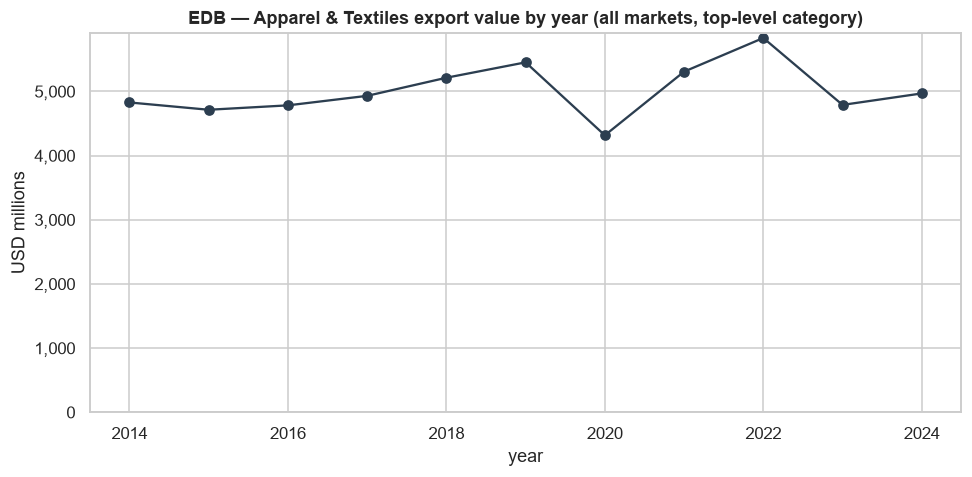

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
edb_total.plot(marker="o", ax=ax, color="#2c3e50")
ax.set_title("EDB — Apparel & Textiles export value by year (all markets, top-level category)")
ax.set_ylabel("USD millions")
ax.set_xlabel("year")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 9. JAAF — monthly Total exports, 2004-2026

276 monthly observations, 2004-01-01 .. 2026-12-01


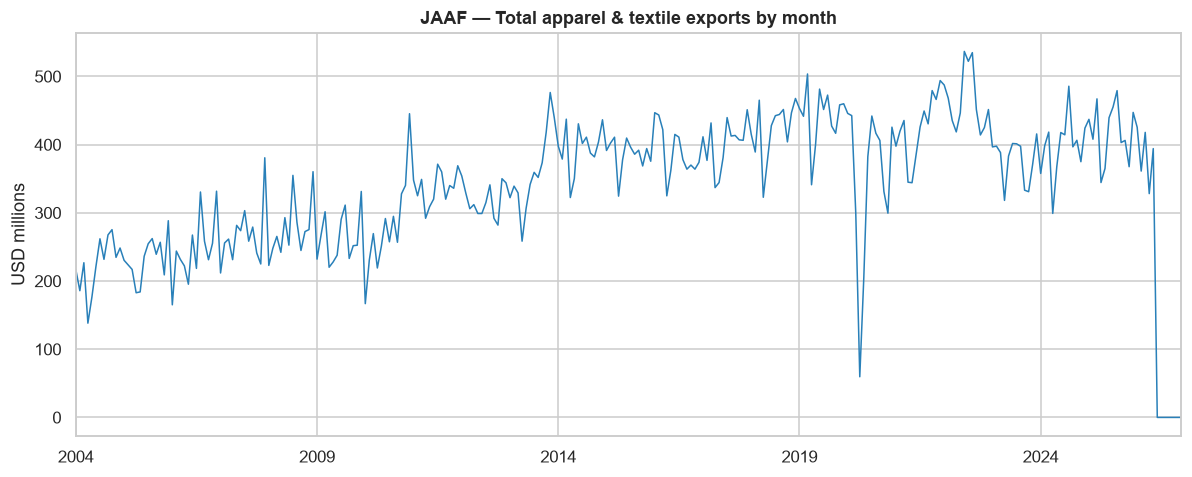

In [19]:
jaaf_total = (
    df[(df["source_id"] == "JAAF") & (df["partner_iso3"].isna())]
    .sort_values("period_start")
    .set_index("period_start")["value_usd_mn"]
)
print(f"{len(jaaf_total)} monthly observations, {jaaf_total.index.min().date()} .. {jaaf_total.index.max().date()}")

fig, ax = plt.subplots(figsize=(11, 4.5))
jaaf_total.plot(ax=ax, color="#2980b9", linewidth=1)
ax.set_title("JAAF — Total apparel & textile exports by month")
ax.set_ylabel("USD millions")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [20]:
# 2026 is a partial, in-progress year per jaaf.PROFILE.md -- confirm the
# "zero-padding" placeholder behavior it describes rather than assume it
y2026 = jaaf_total[jaaf_total.index.year == 2026]
print(y2026)
print(f"\nmonths with an exact 0.00 placeholder value: {(y2026 == 0).sum()} / {len(y2026)}")

period_start
2026-01-01    425.44
2026-02-01    361.20
2026-03-01    417.92
2026-04-01    328.15
2026-05-01    394.14
2026-06-01      0.00
2026-07-01      0.00
2026-08-01      0.00
2026-09-01      0.00
2026-10-01      0.00
2026-11-01      0.00
2026-12-01      0.00
Name: value_usd_mn, dtype: float64

months with an exact 0.00 placeholder value: 7 / 12


**Confirms `jaaf.PROFILE.md`:** 2026 is a partial year with trailing months
recorded as an exact `0.00` placeholder rather than left blank — a naive
"average this year" or "sum this year" calculation run today would silently
understate 2026 rather than error, because zero is numerically valid and
never triggers a null check. Any 2026 aggregate must explicitly exclude the
unpublished months, not just `.dropna()`.

## 10. JAAF seasonality — export value by calendar month

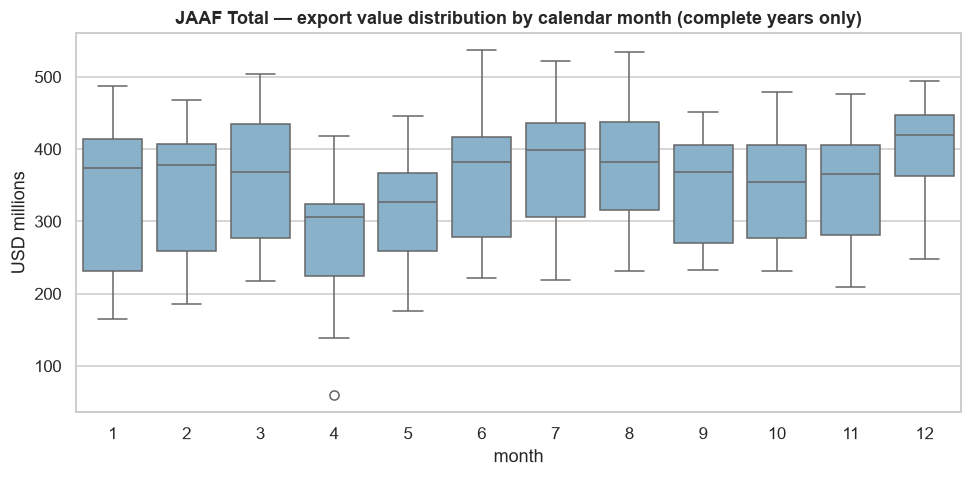

In [21]:
seasonal = df[(df["source_id"] == "JAAF") & (df["partner_iso3"].isna()) & (df["year"] < 2026)].copy()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=seasonal, x="month", y="value_usd_mn", ax=ax, color="#7fb3d5")
ax.set_title("JAAF Total — export value distribution by calendar month (complete years only)")
ax.set_xlabel("month")
ax.set_ylabel("USD millions")
plt.tight_layout()
plt.show()

## 11. EDB — top destination markets

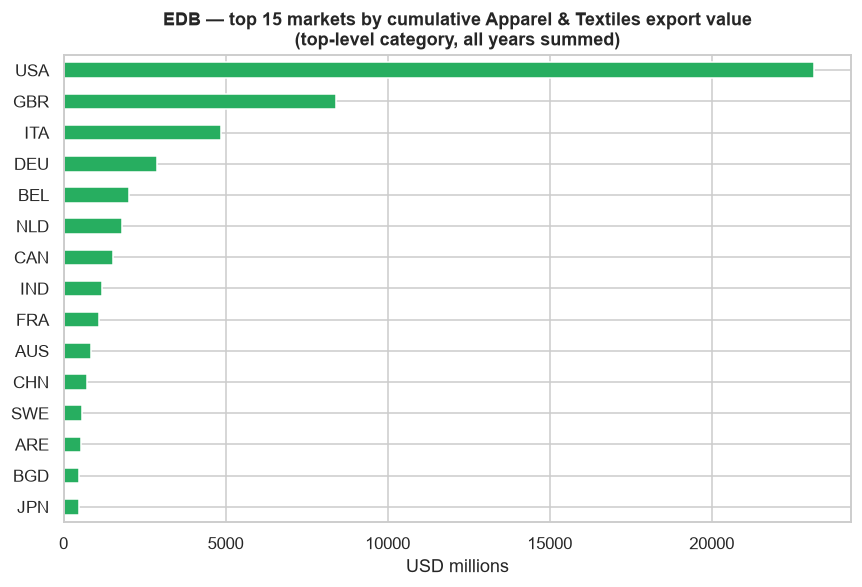

In [22]:
top_partners = (
    df[(df["source_id"] == "EDB") & (df["item_norm"] == edb_total_label)]
    .groupby("partner_iso3")["value_usd_mn"].sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 5.5))
top_partners.sort_values().plot(kind="barh", ax=ax, color="#27ae60")
ax.set_title("EDB — top 15 markets by cumulative Apparel & Textiles export value\n(top-level category, all years summed)")
ax.set_xlabel("USD millions")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 12. Cross-source consistency check — does EDB agree with JAAF?

Both sources separately report USA and UK (GBR) apparel exports. If the two
independently-collected sources broadly agree, that's a strong trust signal;
if they diverge, one of the two connectors likely has a units, scope, or
market-definition issue worth investigating before either is trusted alone.

In [23]:
jaaf_annual_by_partner = (
    df[(df["source_id"] == "JAAF") & (df["partner_iso3"].notna()) & (df["year"] < 2026)]
    .groupby(["partner_iso3", "year"])["value_usd_mn"].sum()
    .rename("jaaf_usd_mn")
)

edb_annual_by_partner = (
    df[(df["source_id"] == "EDB") & (df["item_norm"] == edb_total_label)
       & (df["partner_iso3"].isin(["USA", "GBR"]))]
    .groupby(["partner_iso3", "year"])["value_usd_mn"].sum()
    .rename("edb_usd_mn")
)

compare = pd.concat([jaaf_annual_by_partner, edb_annual_by_partner], axis=1).dropna()
compare["diff_pct"] = (compare["edb_usd_mn"] - compare["jaaf_usd_mn"]) / compare["jaaf_usd_mn"] * 100
compare = compare.sort_index()
compare

jaaf_usd_mn  edb_usd_mn  diff_pct
partner_iso3 year                                   
GBR          2017       827.83      845.28  2.107921
             2018       770.94      789.93  2.463227
             2019       784.58      801.46  2.151470
             2020       591.34      602.38  1.866946
             2021       681.42      690.62  1.350122
             2022       717.11      727.68  1.473972
             2023       626.74      634.13  1.179117
             2024       674.70      682.34  1.132355
USA          2014      2009.30     2015.44  0.305579
             2015      2128.70     2135.70  0.328839
             2016      2122.90     2131.41  0.400867
             2017      2164.00     2170.43  0.297135
             2018      2289.00     2302.25  0.578855
             2019      2364.68     2380.99  0.689734
             2020      1792.97     1806.42  0.750152
             2021      2114.01     2124.54  0.498105
             2022      2332.18     2344.97  0.548414
             2023      1811.59     1824.42  0.708218
             2024      1906.39     1916.60  0.535567

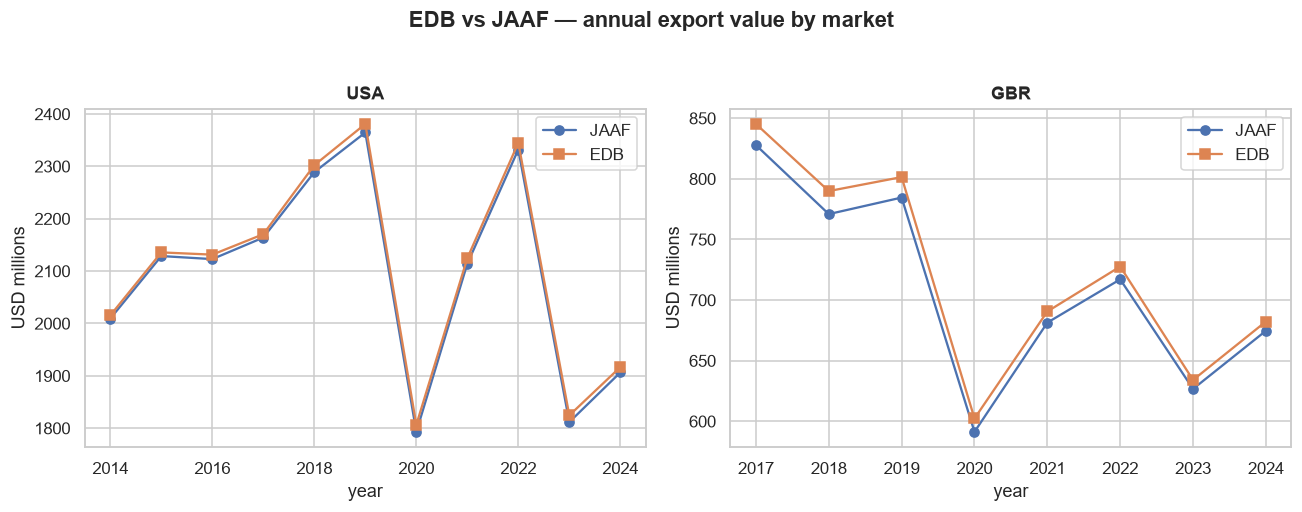

mean |diff_pct| USA: 0.5%
mean |diff_pct| GBR: 1.7%


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for ax, partner in zip(axes, ["USA", "GBR"]):
    sub = compare.loc[partner]
    ax.plot(sub.index, sub["jaaf_usd_mn"], marker="o", label="JAAF")
    ax.plot(sub.index, sub["edb_usd_mn"], marker="s", label="EDB")
    ax.set_title(partner)
    ax.set_xlabel("year")
    ax.set_ylabel("USD millions")
    ax.legend()
plt.suptitle("EDB vs JAAF — annual export value by market", y=1.03, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"mean |diff_pct| USA: {compare.loc['USA', 'diff_pct'].abs().mean():.1f}%")
print(f"mean |diff_pct| GBR: {compare.loc['GBR', 'diff_pct'].abs().mean():.1f}%")

Interpret `diff_pct` as a data-quality signal, not an error to reconcile
away: EDB and JAAF are independent publishers with their own survey
scope/definitions (JAAF's UK figure is exact-matched against its own
market-wise pie chart per `jaaf.PROFILE.md`, so JAAF is internally
consistent) — a small, stable gap is expected; a gap that changes sign or
magnitude sharply year to year would be the actual red flag worth chasing.

## 13. Distribution & outliers

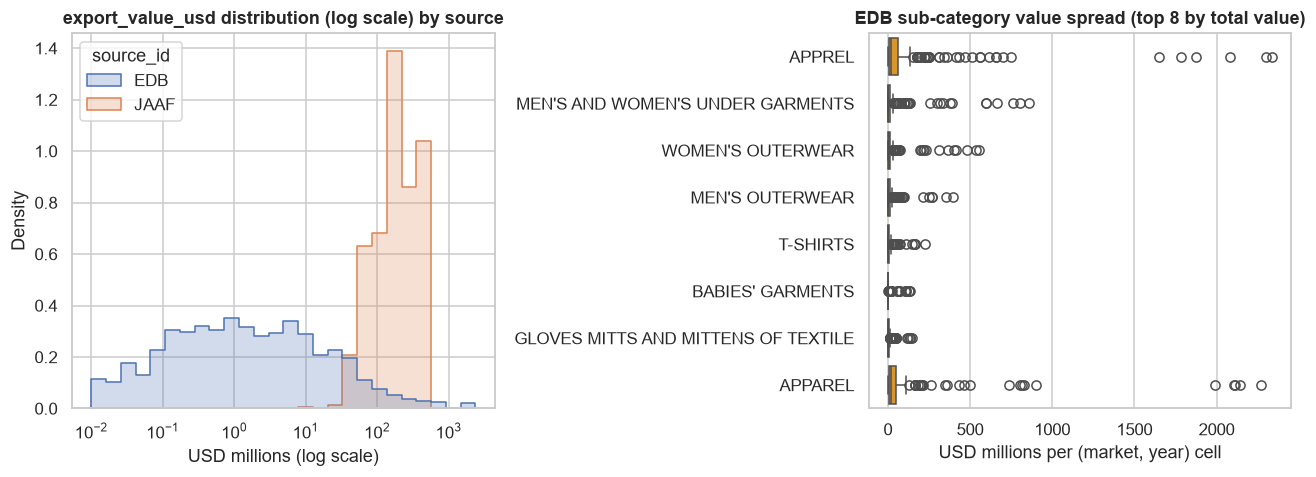

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(
    data=df, x="value_usd_mn", hue="source_id", log_scale=True,
    element="step", stat="density", common_norm=False, ax=axes[0],
)
axes[0].set_title("export_value_usd distribution (log scale) by source")
axes[0].set_xlabel("USD millions (log scale)")

edb_sub = df[(df["source_id"] == "EDB") & (~df["item_norm"].isin([edb_total_label, "TEXTILES"]))]
top_items = edb_sub.groupby("item_norm")["value_usd_mn"].sum().sort_values(ascending=False).head(8).index
sns.boxplot(
    data=edb_sub[edb_sub["item_norm"].isin(top_items)],
    y="item_norm", x="value_usd_mn", ax=axes[1], color="#f39c12",
)
axes[1].set_title("EDB sub-category value spread (top 8 by total value)")
axes[1].set_xlabel("USD millions per (market, year) cell")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [26]:
# flag extreme per-row values -- is any single (market, year) cell implausibly large?
q99 = df["value_usd_mn"].quantile(0.99)
outliers = df[df["value_usd_mn"] > q99][
    ["source_id", "item", "partner_iso3", "year", "value_usd_mn"]
].sort_values("value_usd_mn", ascending=False)
print(f"99th percentile row value: {q99:,.1f} USD mn -- {len(outliers)} rows above it")
outliers.head(10)

99th percentile row value: 528.3 USD mn -- 56 rows above it


,source_id,item,partner_iso3,year,value_usd_mn
0,EDB,"APPAREL & TEXTILES (Made - Up Textile Article, Apparel, Woven Fabrics & Othe...",USA,2019,2380.99
3,EDB,"APPAREL & TEXTILES (Made - Up Textile Article, Apparel, Woven Fabrics & Othe...",USA,2022,2344.97
200,EDB,APPREL,USA,2019,2338.33
6187,EDB,"APPAREL AND TEXTILES (Made – Up Textile Articles, Apparel, Woven Fabrics, Ot...",USA,2018,2302.25
203,EDB,APPREL,USA,2022,2300.24
6570,EDB,APPAREL,USA,2018,2269.47
6186,EDB,"APPAREL AND TEXTILES (Made – Up Textile Articles, Apparel, Woven Fabrics, Ot...",USA,2017,2170.43
6569,EDB,APPAREL,USA,2017,2140.42
6184,EDB,"APPAREL AND TEXTILES (Made – Up Textile Articles, Apparel, Woven Fabrics, Ot...",USA,2015,2135.70
6185,EDB,"APPAREL AND TEXTILES (Made – Up Textile Articles, Apparel, Woven Fabrics, Ot...",USA,2016,2131.41


## 14. Year-over-year growth

In [27]:
edb_yoy = edb_total.pct_change() * 100
jaaf_full_years = jaaf_total[jaaf_total.index.year < 2026].resample("YE").sum()
jaaf_full_years.index = jaaf_full_years.index.year
jaaf_yoy = jaaf_full_years.pct_change() * 100

growth = pd.DataFrame({"EDB_yoy_pct": edb_yoy, "JAAF_yoy_pct": jaaf_yoy}).dropna(how="all").round(1)
growth

,EDB_yoy_pct,JAAF_yoy_pct
2005,NaN,3.7
2006,NaN,6.0
2007,NaN,8.5
2008,NaN,3.6
2009,NaN,-4.8
2010,NaN,6.1
2011,NaN,20.5
2012,NaN,-5.4
2013,NaN,12.9
2014,NaN,9.8


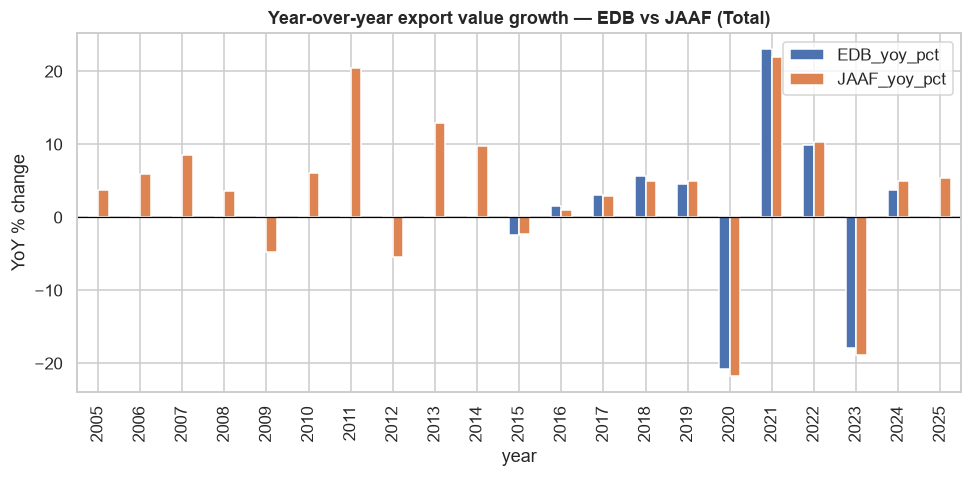

In [28]:
fig, ax = plt.subplots(figsize=(9, 4.5))
growth.plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Year-over-year export value growth — EDB vs JAAF (Total)")
ax.set_ylabel("YoY % change")
ax.set_xlabel("year")
plt.tight_layout()
plt.show()

## 15. Do EDB sub-categories move together?

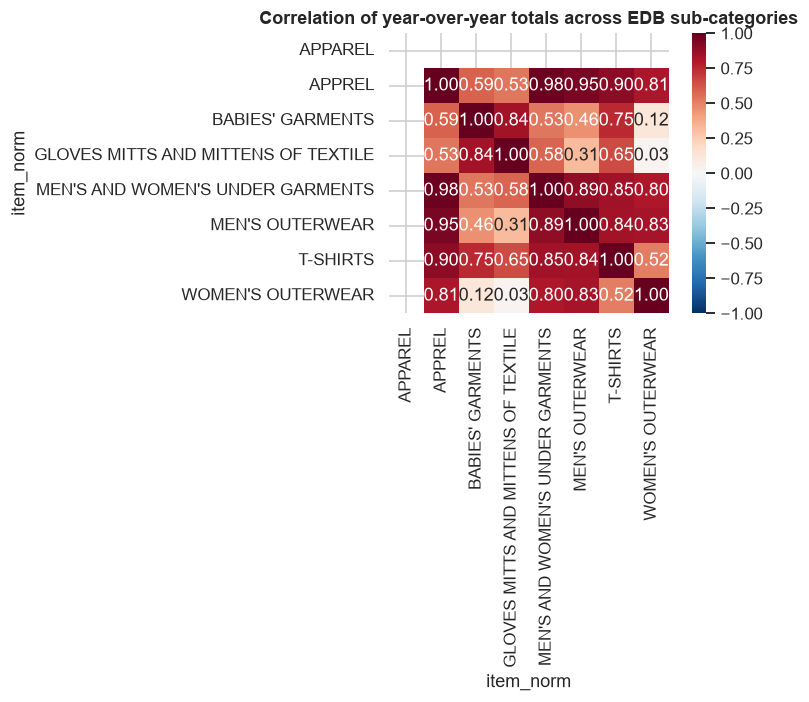

In [29]:
pivot = (
    edb_sub[edb_sub["item_norm"].isin(top_items)]
    .groupby(["item_norm", "year"])["value_usd_mn"].sum()
    .unstack("item_norm")
)
pivot = pivot.dropna(thresh=int(len(pivot.columns) * 0.6))  # keep years with decent coverage

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(pivot.corr(), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Correlation of year-over-year totals across EDB sub-categories")
plt.tight_layout()
plt.show()

## 16. Data-quality findings — summary

| # | Finding | Source | Severity | Where confirmed |
|---|---|---|---|---|
| 1 | **EDB's overlapping PDF editions (2023 ed. covers 2019-2023, 2024 ed. covers 2020-2024) land in `fact_trade` as exact duplicate rows for the shared 2020-2023 years** | EDB | **High** — silently ~doubles 2020-2023 in a naive `groupby(year).sum()`; not documented in `edb.PROFILE.md` | §5 |
| 2 | `hs_code`, `export_volume`, `volume_unit`, `price`, `price_unit`, `fx_usd_lkr` are 100% null for both sources | EDB, JAAF | Expected (schema is shared across all connectors) | §3 |
| 3 | Null `partner_iso3` is exclusively JAAF's "Total" world-aggregate rows, not a parsing gap | JAAF | Expected | §3 |
| 4 | `APPAREL` / `APPREL` typo split across editions as distinct `item` values | EDB | Medium — breaks naive string-equality grouping | §6 |
| 5 | 3-way punctuation drift on "Made-Up Textile Articles" across editions, incl. a `�` mojibake variant (new finding, not in `edb.PROFILE.md`) | EDB | Medium — same root cause as the documented `table_id` instability | §6 |
| 6 | Summing `export_value_usd` across all EDB items per year overstates real exports several-fold (category hierarchy, not a flat partition) | EDB | High if used naively — must pick one top-level item per edition | §7 |
| 7 | 2026 (partial year) JAAF months are `0.00` placeholders, not blank/null | JAAF | Medium — confirmed live, matches `jaaf.PROFILE.md` | §9 |
| 8 | EDB vs JAAF USA/GBR annual totals track each other closely once duplicates are removed, including matching the 2020 COVID-year drop | EDB, JAAF | Informational — strong cross-source trust signal | §12 |

**Suggested follow-ups for the connector/crosswalk layer** (not implemented
here — this notebook is analysis, not a fix):
- Deduplicate `to_fact_trade` output for EDB on overlapping edition years
  (e.g. prefer the most-recently-published edition for any year both cover)
  instead of relying on every downstream consumer to `drop_duplicates` on
  `source_hash` themselves.
- A normalized item-taxonomy crosswalk for EDB (case-fold, dash-normalize,
  strip parenthetical detail) so the same category groups across editions
  without each downstream consumer reinventing `normalize_item()`.
- Re-check the archive-layout (2014-2018) PDF text extraction for the
  `�` mojibake — likely an encoding mismatch specific to that file,
  worth fixing at the source rather than normalizing around it forever.
- Decide and document, once, which single `item` value is "the" apparel+
  textiles total per source — this notebook picked
  `APPAREL AND TEXTILES` after normalization, but that's an EDA-time choice,
  not a contract.